In [38]:
#loading the dictionary from another file
import json

with open("consensus_dict.json", "r") as f:
    consensus_dict = json.load(f)

print(consensus_dict)

with open("cleaned_antigen_map", "r") as f:
    cleaned_antigen_map = json.load(f)

print(cleaned_antigen_map)

def hamming_dist(seq1, seq2):
    return sum(a != b for a, b in zip(seq1, seq2))

color_map = {
    'homo sapiens': 'red',
    'SARS-CoV-2': 'blue',
    'both': 'purple'
}


{'IGKV1': 'MD_K___IHNHHK___________________DIQMTQSPSSLSASVGDRVTITCRASQ___Y_______L_WYQQKPGKAPKLLIY_AST_L_SGVPSRFSSRATLTGSGSGTDFTLTISSLQPEDFATYYCQQ__________TFG_GTKVEIKR_T_VAAPSVFIFS__PPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGECS__________QLIMVTNKAIASQ', 'IGLV1': 'MGILPSPGM_______L_L_____G__S_QSVLTQPPS_S__PGQRVTISC_GS_SNLY_NIG____V_WYQQQLPG_APKLLIY____RPSGVPDRFSGSKSGSSTSASLAI_GLQ_EDEADYYC___D_SL_____VFGGGTK_TVL_TKLTVLGQPKAAPSVTLFPPSSEELQANKATLVCLISDFYPGAVTVAWKADSSPVKAGSVETTTPSKQSNNKYAASSYLSLTPEQWKSHRSYSCQVTHEGSSSTVEKTVAPTECSAAENLYFQGS', 'IGKV3': 'PNITNLCP____________L_________NCVAEIV_TQSP_TLSLSPGERATLSCRASQSV___DLCFTNVYA_______LAWYQQKPGQAPRLLIY_AS_RATGIP_RFSGSGSGTDFTLTIS_LEPEDFAVYYCQQ____PS____TFG_GTKVQ_EIKRT___PTVSIFPPSSEQLTSGGASVVCFTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGEC____Q______TNGVGY_______LS_A_________C__T__GL____________H', 'IGKV6': 'DIV_TQ___F_S_S____V_ITC_ASQ_

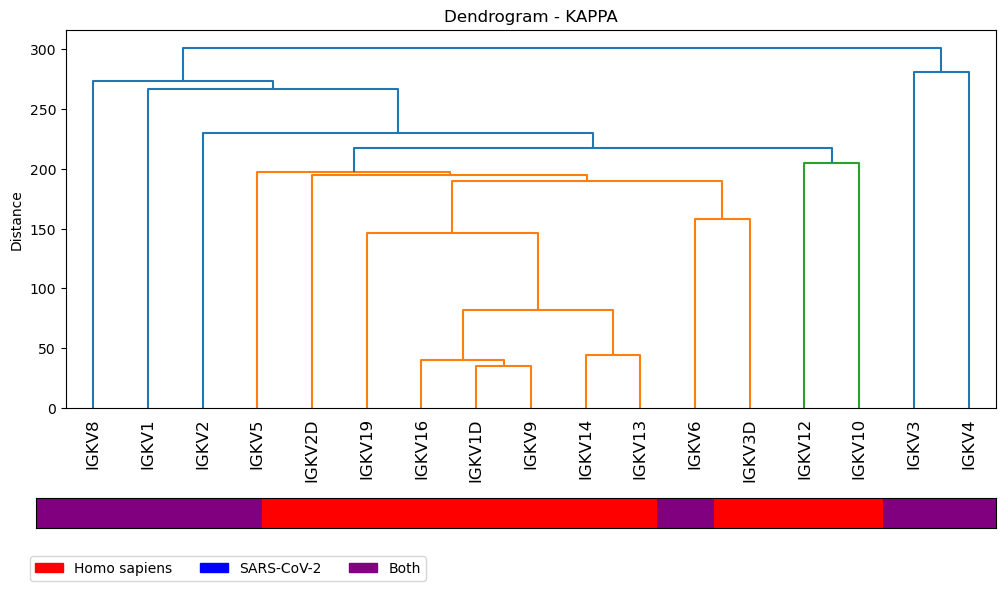

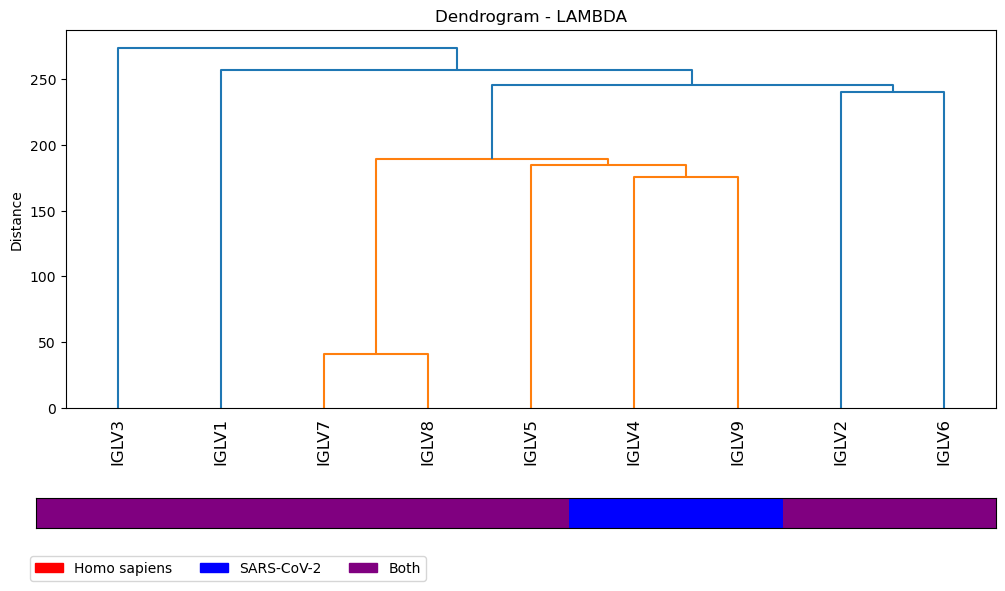

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.patches as mpatches

def pad(seq, length):
    return seq + "_" * (length - len(seq))

def cluster_and_plot(consensus_dict, cleaned_antigen_map, color_map, title_prefix=""):
    labels = list(consensus_dict.keys())
    sequences = list(consensus_dict.values())

    dist_matrix = np.array([[hamming_dist(s1, s2) for s2 in sequences] for s1 in sequences])
    linkage_matrix = linkage(squareform(dist_matrix), method="average")

    fig, ax = plt.subplots(figsize=(12, 6))
    plt.subplots_adjust(bottom=0.25)

    dendro = dendrogram(linkage_matrix, labels=labels, leaf_rotation=90, ax=ax)
    ax.set_title(f"Dendrogram - {title_prefix}")
    ax.set_ylabel("Distance")

    # Get order of labels from dendrogram
    label_order = dendro["ivl"]
    species_list = [cleaned_antigen_map.get(label, "") for label in label_order]
    color_names = [color_map.get(species, "gray") for species in species_list]
    rgb_colors = [to_rgb(c) for c in color_names]

    # Add color strip as image (RGB values)
    color_ax = fig.add_axes([0.1, 0.05, 0.8, 0.05])
    color_ax.imshow([rgb_colors], aspect="auto")
    color_ax.set_xticks([])
    color_ax.set_yticks([])
 
    legend_patches = [
        mpatches.Patch(color=color_map["homo sapiens"], label="Homo sapiens"),
        mpatches.Patch(color=color_map["SARS-CoV-2"], label="SARS-CoV-2"),
        mpatches.Patch(color=color_map["both"], label="Both")
    ]
    plt.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.2, -2), ncol=3)

    plt.show()


# Plot
cluster_and_plot(kappa_consensus_padded, cleaned_antigen_map, color_map, title_prefix="KAPPA")
cluster_and_plot(lambda_consensus_padded, cleaned_antigen_map, color_map, title_prefix="LAMBDA")
